In [11]:
import pandas as pd
import numpy as np
import joblib, os
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE


In [13]:
# 1. Load
df = pd.read_csv("../data/telco_churn_clean.csv")

In [14]:
# 2. Feature engineering
df["AvgMonthlySpend"] = df["TotalCharges"] / df["tenure"]
services = ["OnlineSecurity","OnlineBackup","DeviceProtection",
            "TechSupport","StreamingTV","StreamingMovies"]
df["ServiceCount"] = df[services].apply(lambda r: (r == "Yes").sum(), axis=1)

# 3. Encode
binary_cols = ["Partner","Dependents","PhoneService","PaperlessBilling","Churn"]
df[binary_cols] = df[binary_cols].replace({"Yes":1, "No":0})
df["gender"] = df["gender"].map({"Female":1, "Male":0}).fillna(0).astype(int)

ohe_cols = ["MultipleLines","InternetService","OnlineSecurity","OnlineBackup",
            "DeviceProtection","TechSupport","StreamingTV","StreamingMovies",
            "Contract","PaymentMethod"]
df = pd.get_dummies(df, columns=ohe_cols, drop_first=True)

# 4. Verify — must be empty
print("Non-numeric cols:", X.select_dtypes('object').columns.tolist() if 'X' in dir() else df.select_dtypes('object').columns.tolist())

# 5. Split
X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# 6. Scale
num_cols = ["tenure","MonthlyCharges","TotalCharges","AvgMonthlySpend","ServiceCount"]
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols]  = scaler.transform(X_test[num_cols])

# 7. SMOTE
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
print("Done:", X_train_sm.shape)

# 8. Save
os.makedirs("../data", exist_ok=True)
os.makedirs("../models", exist_ok=True)
X_train_sm.to_csv("../data/X_train.csv", index=False)
X_test.to_csv("../data/X_test.csv", index=False)
y_train_sm.to_csv("../data/y_train.csv", index=False)
y_test.to_csv("../data/y_test.csv", index=False)
joblib.dump(scaler, "../models/scaler.pkl")
print("Saved.")

Non-numeric cols: []
Done: (8244, 32)
Saved.


C:\Users\karti\AppData\Local\Temp\ipykernel_19796\1998602030.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[binary_cols] = df[binary_cols].replace({"Yes":1, "No":0})


In [15]:
# Save preprocessed data at the end of preprocessing notebook
import joblib

X_train_sm.to_csv("../data/X_train.csv", index=False)
X_test.to_csv("../data/X_test.csv", index=False)
y_train_sm.to_csv("../data/y_train.csv", index=False)
y_test.to_csv("../data/y_test.csv", index=False)

joblib.dump(scaler, "../models/scaler.pkl")

print("Saved.")

Saved.


In [18]:
pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/101.7 MB 390.1 kB/s eta 0:04:20
   ---------------------------------------- 0.5/101.7 MB 390.1 kB/s eta 0:04:20
   ---------------------------------------- 0.5/101.7 MB 390.1 kB/s eta 0:04:20
   ---------------------------------------- 0.5/101.7 MB 390.1 kB/s eta 0:04:20
   ---------------------------------------- 0.5/101.7 MB 390.1 kB/s eta 0:04:20
   ---------------------------------------- 0.5/101.7 MB 390.1 kB/s eta 0:04:20
   ---------------------------------------- 0.5/101.7 MB 390.1 kB/s eta 0:04:20
   -----------


── LogisticRegression ──
              precision    recall  f1-score   support

           0       0.87      0.79      0.83      1031
           1       0.54      0.68      0.60       371

    accuracy                           0.76      1402
   macro avg       0.71      0.74      0.72      1402
weighted avg       0.78      0.76      0.77      1402

ROC-AUC: 0.8369

── RandomForest ──
              precision    recall  f1-score   support

           0       0.86      0.82      0.84      1031
           1       0.56      0.61      0.58       371

    accuracy                           0.77      1402
   macro avg       0.71      0.72      0.71      1402
weighted avg       0.78      0.77      0.77      1402

ROC-AUC: 0.8195


c:\Users\karti\anaconda3\envs\python_course\Lib\site-packages\xgboost\training.py:200: UserWarning: [12:21:25] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



── XGBoost ──
              precision    recall  f1-score   support

           0       0.85      0.82      0.84      1031
           1       0.55      0.60      0.57       371

    accuracy                           0.76      1402
   macro avg       0.70      0.71      0.70      1402
weighted avg       0.77      0.76      0.77      1402

ROC-AUC: 0.8212

Best model: LogisticRegression


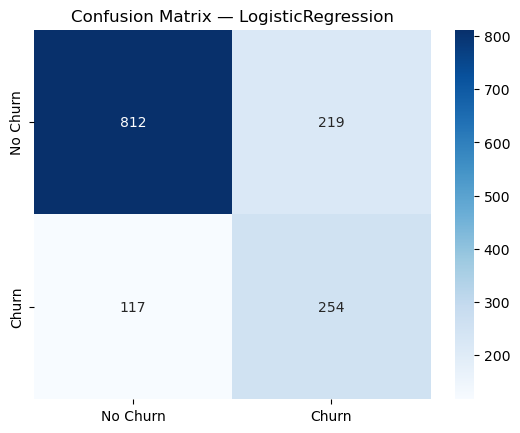

Model saved.


In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load
X_train = pd.read_csv("../data/X_train.csv")
X_test  = pd.read_csv("../data/X_test.csv")
y_train = pd.read_csv("../data/y_train.csv").values.ravel()
y_test  = pd.read_csv("../data/y_test.csv").values.ravel()

# 2. Train 3 models
models = {
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=42),
    "RandomForest":       RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost":            XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]
    auc = roc_auc_score(y_test, y_prob)
    results[name] = {"model": model, "auc": auc, "y_pred": y_pred}
    print(f"\n── {name} ──")
    print(classification_report(y_test, y_pred))
    print(f"ROC-AUC: {auc:.4f}")

# 3. Pick best model
best_name = max(results, key=lambda k: results[k]["auc"])
best_model = results[best_name]["model"]
print(f"\nBest model: {best_name}")

# 4. Confusion matrix of best model
cm = confusion_matrix(y_test, results[best_name]["y_pred"])
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Churn","Churn"],
            yticklabels=["No Churn","Churn"])
plt.title(f"Confusion Matrix — {best_name}")
plt.show()

# 5. Save best model
joblib.dump(best_model, "../models/best_model.pkl")
print("Model saved.")